# Acoustic Contour Metric Convergence Analysis

This notebook validates the convergence of acoustic contour metrics with respect to number of revolutions and observation times per revolution.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.DataLoader import load_propeller_dict
from LFProp.Utils import get_oaspl_contour_area
import scienceplots

plt.style.use(['science', 'no-latex'])

In [2]:
# Load propeller geometry
prop_name, blade_dict = load_propeller_dict('APC Dicts/10x7E')[0]

# Define observer grid
n_observers_per_side = 12
size = 5
x_range = np.linspace(-size, size, n_observers_per_side)
y_range = np.linspace(0, size, n_observers_per_side)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)
r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

print(f'Observer grid: {n_observers_per_side} x {n_observers_per_side} = {len(r_observers)} observers')

Observer grid: 12 x 12 = 144 observers


In [3]:
# Test parameter ranges
revolutions_range = np.linspace(1, 10, 10, dtype=int)
num_obs_times_per_rev_range = np.linspace(10, 100, 10, dtype=int)

# Storage for results
oaspl_values = {}  # Dictionary: (revs, num_obs) -> OASPL array
computation_times = {}  # Dictionary: (revs, num_obs) -> time in seconds

print('Running convergence analysis...')
print(f'Testing {len(revolutions_range)} revolutions x {len(num_obs_times_per_rev_range)} obs_times configurations')
print()

for revolutions in revolutions_range:
    for num_obs_times_per_rev in num_obs_times_per_rev_range:
        params = LowFidelityParameters(
            rpm=7000,
            a_inf=343,
            rho=1.225,
            mu=1.81e-5,
            n_blades=blade_dict['n_blades'],
            p_ref=2e-5,
            revolutions=revolutions,
            num_obs_times_per_rev=num_obs_times_per_rev,
            device='cuda',
        )
        
        propeller = Propeller(
            geometry=blade_dict,
            params=params,
        )
        
        # Run BEMT
        propeller.run_bemt(v_inf=0.0)
        
        # Run aeroacoustics
        propeller.run_aeroacoustics(
            observer_positions=r_observers,
            lt=1,
            i=1e-3,
            alpha_stall=15,
            keep_bpm_components=False
        )
        propeller.postprocess()

        propeller.third_octave_total_oaspl = propeller.third_octave_total_oaspl.reshape(n_observers_per_side, n_observers_per_side)
        propeller.third_octave_total_oaspl = np.vstack([
            propeller.third_octave_total_oaspl[::-1, :],     # Flip for negative y
            propeller.third_octave_total_oaspl[1:, :]        # Original positive y, skip y=0 to avoid duplication
        ])
        # Store results
        key = (revolutions, num_obs_times_per_rev)
        area = get_oaspl_contour_area(propeller, target_level=60, size=size, weight_below=1)
        oaspl_values[key] = area
        
        # Calculate mean OASPL for reference
        print(f'revolutions={revolutions:2d}, num_obs_times_per_rev={num_obs_times_per_rev:3d} -> '
              f'Contour Area={area:.2f} dB(A)')


Running convergence analysis...
Testing 10 revolutions x 10 obs_times configurations

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 256.779 ms
[CUDA TIMING] BPM.__init__: 0.774 ms
[CUDA TIMING] get_observer_times: 44.042 ms
[CUDA TIMING] calculate_f1a_pressure: 100.971 ms
[CUDA TIMING] combine_sources (F1A): 59.843 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 349.742 ms
[CUDA TIMING] BPM.run_forward_bpm: 121.447 ms
[CUDA TIMING] combine_sources_bpm: 0.649 ms
revolutions= 1, num_obs_times_per_rev= 10 -> Contour Area=24.45 dB(A)
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 3.299 ms
[CUDA TIMING] BPM.__init__: 0.679 ms
[CUDA TIMING] get_observer_times: 0.338 ms
[CUDA TIMING] calculate_f1a_pressure: 6.505 ms
[CUDA TIMING] combine_sources (F1A): 1.313 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 26.534 ms
[CUDA TIMING] BPM.run_forward_bpm: 37.736 ms
[CUDA TIMING] combine_sources_bpm: 0.165 ms
revolutions= 1, num_obs_times_per_rev= 20 -> Contour Area=24.46 dB

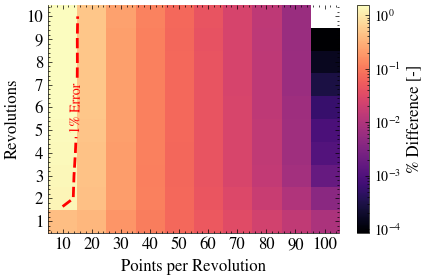

In [4]:
from matplotlib.colors import LogNorm, PowerNorm

# Create 2D heatmap: revolutions vs points_per_rev, colored by difference from reference
ref_key = (revolutions_range[-1], num_obs_times_per_rev_range[-1])
ref_value = oaspl_values[ref_key]

# Create 2D array for heatmap
heatmap_data = np.zeros((len(revolutions_range), len(num_obs_times_per_rev_range)))

for i, revolutions in enumerate(revolutions_range):
    for j, num_obs_times in enumerate(num_obs_times_per_rev_range):
        key = (revolutions, num_obs_times)
        heatmap_data[i, j] = 100 * np.abs((oaspl_values[key] - ref_value) / ref_value)

# Create figure and heatmap
fig, ax = plt.subplots(figsize=(4.5, 3))

# Plot heatmap
im = ax.imshow(
    heatmap_data,
    cmap='magma',
    norm=LogNorm(vmin=heatmap_data[heatmap_data > 0].min(), vmax=heatmap_data.max()), # Use LogNorm
    aspect='auto',
    origin='lower',
    interpolation='nearest'
)
X, Y = np.meshgrid(np.arange(len(num_obs_times_per_rev_range)), 
                   np.arange(len(revolutions_range)))

contour = ax.contour(X, Y, heatmap_data, levels=[1], 
                     colors='red', linestyles='--', linewidths=2)

ax.clabel(contour, inline=True, fmt='1%% Error', fontsize=10)

# Set ticks and labels
ax.set_xticks(np.arange(len(num_obs_times_per_rev_range)))
ax.set_yticks(np.arange(len(revolutions_range)))
ax.set_xticklabels(num_obs_times_per_rev_range, fontsize=12)
ax.set_yticklabels(revolutions_range, fontsize=12)

# Labels and formatting
ax.set_xlabel('Points per Revolution', fontsize=12)
ax.set_ylabel('Revolutions', fontsize=12)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('% Difference [-]', fontsize=12)

# Remove top and right spines
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Figures/Validation/convergence_2d_heatmap.png', dpi=200)
plt.show()